In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
swe = pd.read_csv('/home/py/groundwater/data/bow_valley/swe/swe_long.csv', parse_dates=["survey_date"])
swe_peak = swe.groupby(["station_code", "water_year"]).swe_mm.max().reset_index()

In [4]:
ACIS = Path("/home/py/groundwater/data/acis/processed")
ECCC = Path("/home/py/groundwater/data/eccc/processed")

<Axes: xlabel='date'>

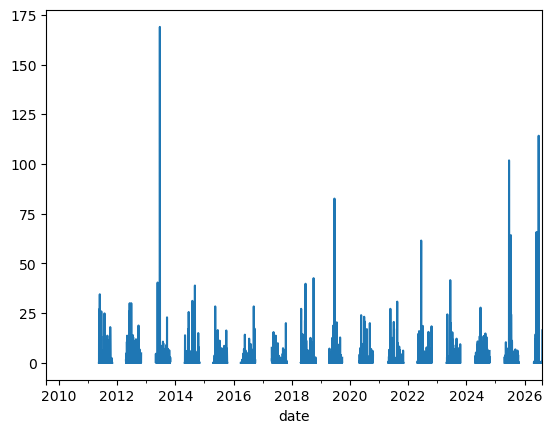

In [34]:
kan_ba = pd.read_csv(ACIS / "Kananaskis_Boundary_Auto.csv", parse_dates=[0], index_col=0, usecols=[0,2]).squeeze()
kan_ba.plot()

<Axes: xlabel='date'>

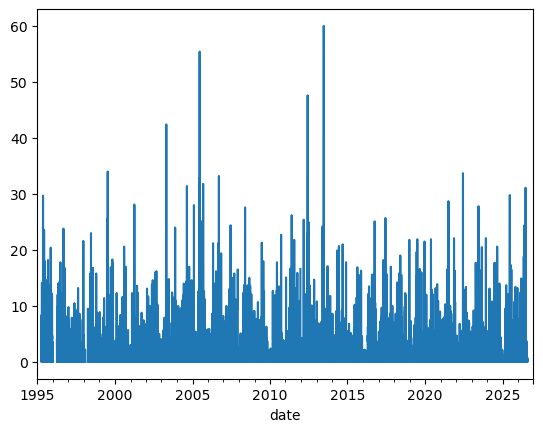

In [35]:
banff_cs = pd.read_csv(ECCC / "3050519_BANFF_CS.csv", parse_dates=[0], usecols=[0, 12], index_col=0).squeeze()
banff_cs.plot()

<Axes: xlabel='date'>

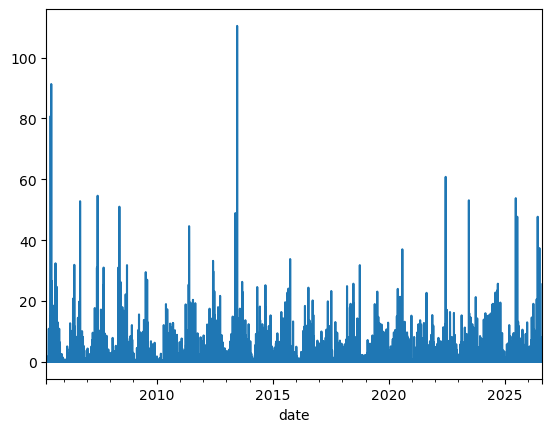

In [36]:
bv = pd.read_csv(ACIS / "Bow_Valley.csv", parse_dates=[0], index_col=0, usecols=[0,2]).squeeze()
bv.plot()

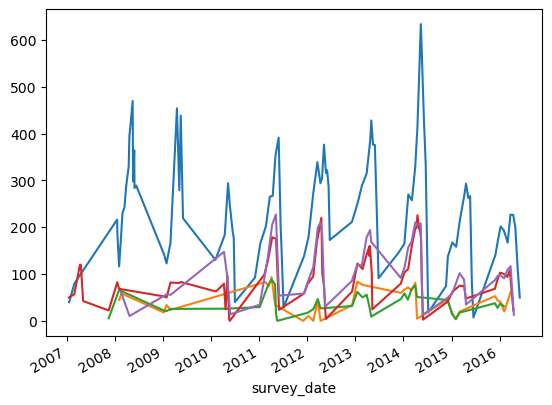

In [59]:
swe_dfs = {}

for station, df in swe.groupby('station'):
    swe_dfs[station] = df
    swe_dfs[station].index = pd.to_datetime(swe_dfs[station]['survey_date'])
    swe_dfs[station] = swe_dfs[station]['swe_mm']
    swe_dfs[station].plot()

In [54]:
swe_dfs.keys()

dict_keys(['Fisera Ridge', 'Hay Meadow', 'Level Forest', 'Upper Clearing', 'Vista View'])

<Axes: xlabel='survey_date'>

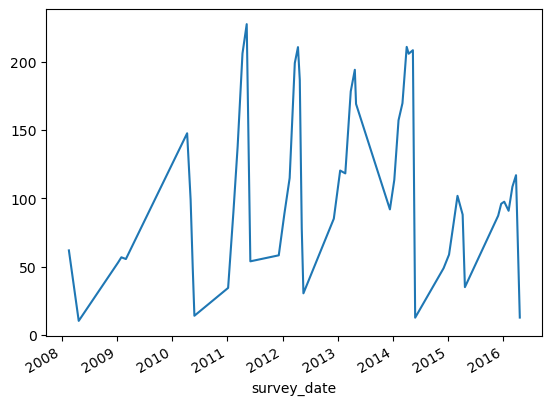

In [60]:
swe_dfs['Vista View'].plot()

<Axes: xlabel='date'>

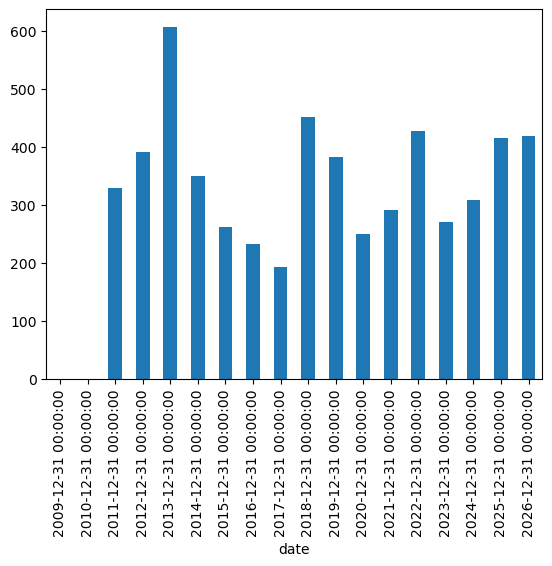

In [71]:
kan_ba.resample('YE').sum().plot(kind='bar')